# EDA hospitilization data
This notebook looks at a potential source for hospitilization data:
1. [COVID-19 Reported Patient Impact and Hospital Capacity by Facility](https://healthdata.gov/Hospital/COVID-19-Reported-Patient-Impact-and-Hospital-Capa/anag-cw7u/about_data)

In [48]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from tqdm import tqdm


## 1. COVID-19 Reported Patient Impact and Hospital Capacity by Facility

In [4]:
# Load data with proper dtype specifications to avoid mixed type warnings
df = pd.read_csv("../../data/raw/COVID-19_Reported_Patient_Impact_and_Hospital_Capacity_by_Facility_20251026.csv", low_memory=False)
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1045406 entries, 0 to 1045405
Columns: 128 entries, hospital_pk to total_staffed_pediatric_icu_beds_7_day_sum
dtypes: bool(2), float64(2), int64(29), object(95)
memory usage: 1006.9+ MB
None


,hospital_pk,collection_week,state,ccn,hospital_name,address,city,zip,hospital_subtype,fips_code,...,previous_day_admission_pediatric_covid_confirmed_unknown_7_day_sum,staffed_icu_pediatric_patients_confirmed_covid_7_day_avg,staffed_icu_pediatric_patients_confirmed_covid_7_day_coverage,staffed_icu_pediatric_patients_confirmed_covid_7_day_sum,staffed_pediatric_icu_bed_occupancy_7_day_avg,staffed_pediatric_icu_bed_occupancy_7_day_coverage,staffed_pediatric_icu_bed_occupancy_7_day_sum,total_staffed_pediatric_icu_beds_7_day_avg,total_staffed_pediatric_icu_beds_7_day_coverage,total_staffed_pediatric_icu_beds_7_day_sum
0,370094,2021/01/10,OK,370094,SSM HEALTH ST ANTHONY HOSPITAL - MIDWEST,2825 PARKLAWN DRIVE,MIDWEST CITY,73110.0,Short Term,40109.0,...,NaN,NaN,0,NaN,0,3,0,0,3,0
1,370220,2020/06/14,OK,370220,ONECORE HEALTH,100 NE 85TH STREET,OKLAHOMA CITY,73114.0,Short Term,40109.0,...,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN
2,431338,2022/12/25,SD,431338,AVERA GREGORY HOSPITAL,110 S LOGAN AVE,GREGORY,57533.0,Critical Access Hospitals,46053.0,...,0,0,7,0,0,7,0,0,7,0
3,450424,2020/10/18,TX,450424,HOUSTON METHODIST BAYTOWN HOSPITAL,4401 GARTH ROAD,BAYTOWN,77521.0,Short Term,48201.0,...,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN
4,453316,2020/08/02,TX,453316,CHILDRENS MEDICAL CENTER PLANO,7601 PRESTON ROAD,PLANO,75024.0,Childrens Hospitals,48085.0,...,NaN,NaN,0,NaN,NaN,0,NaN,NaN,0,NaN


### Hospital count time series

Dataset temporal range: 2019-12-29 to 2024-04-21
Total timespan: 225.0 weeks
Total data points: 1045406
Expected weeks: 226
Actual weeks in data: 226

No gaps detected in national-level reporting


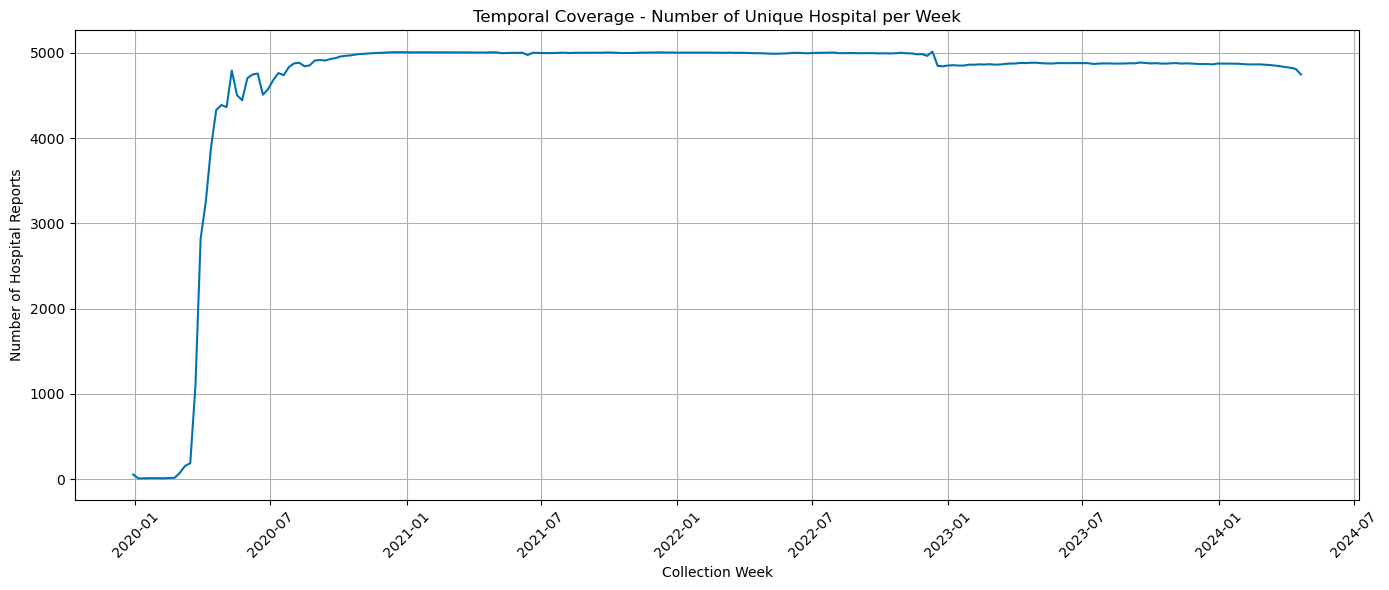

In [37]:
df['collection_week'] = pd.to_datetime(df['collection_week'])
df = df.sort_values('collection_week')

# Get week range
start_date = df['collection_week'].min()
end_date = df['collection_week'].max()
total_weeks = (end_date - start_date).days / 7

print(f"Dataset temporal range: {start_date.date()} to {end_date.date()}")
print(f"Total timespan: {total_weeks:.1f} weeks")
print(f"Total data points: {len(df)}")

# Get all unique weeks
all_weeks = df['collection_week'].unique()
expected_weeks = pd.date_range(start=start_date, end=end_date, freq='W')
print(f"Expected weeks: {len(expected_weeks)}")
print(f"Actual weeks in data: {len(all_weeks)}")

# Check for gaps after aggregating
gaps = []
for i in range(len(expected_weeks) - 1):
    expected_next = expected_weeks[i + 1]
    if expected_next not in all_weeks:
        gaps.append((expected_weeks[i], expected_next))

if gaps:
    print(f"\nGaps in national-level reporting found: {len(gaps)}")
    for gap_start, gap_end in gaps[:5]:  # Show first 5 gaps
        print(f"  - Gap between {gap_start.date()} and {gap_end.date()}")
else:
    print("\nNo gaps detected in national-level reporting")

# plot unique hospital counts
temporal_coverage = df.groupby('collection_week')['hospital_pk'].nunique()
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(temporal_coverage.index, temporal_coverage.values)
ax.set_xlabel('Collection Week')
ax.set_ylabel('Number of Hospital Reports')
ax.set_title('Temporal Coverage - Number of Unique Hospital per Week')
ax.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Hospital reporting gaps

Total hospitals in dataset: 5172

Reporting continuity statistics:
  Hospitals with continuous reporting: 3671 (71.0%)
  Hospitals with gaps in reporting: 1501 (29.0%)
  Hospitals with >2 missing weeks: 873 (16.9%)


=== Hospital Reporting Start/Stop Analysis ===
Earliest hospital start date: 2019-12-29 00:00:00
Latest hospital start date: 2024-03-24 00:00:00
Earliest hospital stop date: 2020-04-05 00:00:00
Latest hospital stop date: 2024-04-21 00:00:00


Hospitals starting to report by year-month:
start_year_month
2019-12      53
2020-01       2
2020-02      11
2020-03    2792
2020-04    1777
2020-05     283
2020-06      68
2020-07      35
2020-08      14
2020-09      10
Freq: M, Name: count, dtype: int64


Hospitals stopping to report by year-month:
stop_year_month
2023-07       7
2023-08       2
2023-09      18
2023-10       5
2023-11       6
2023-12       4
2024-01      10
2024-02       7
2024-03      40
2024-04    4829
Freq: M, Name: count, dtype: int64


Hospitals still reporting

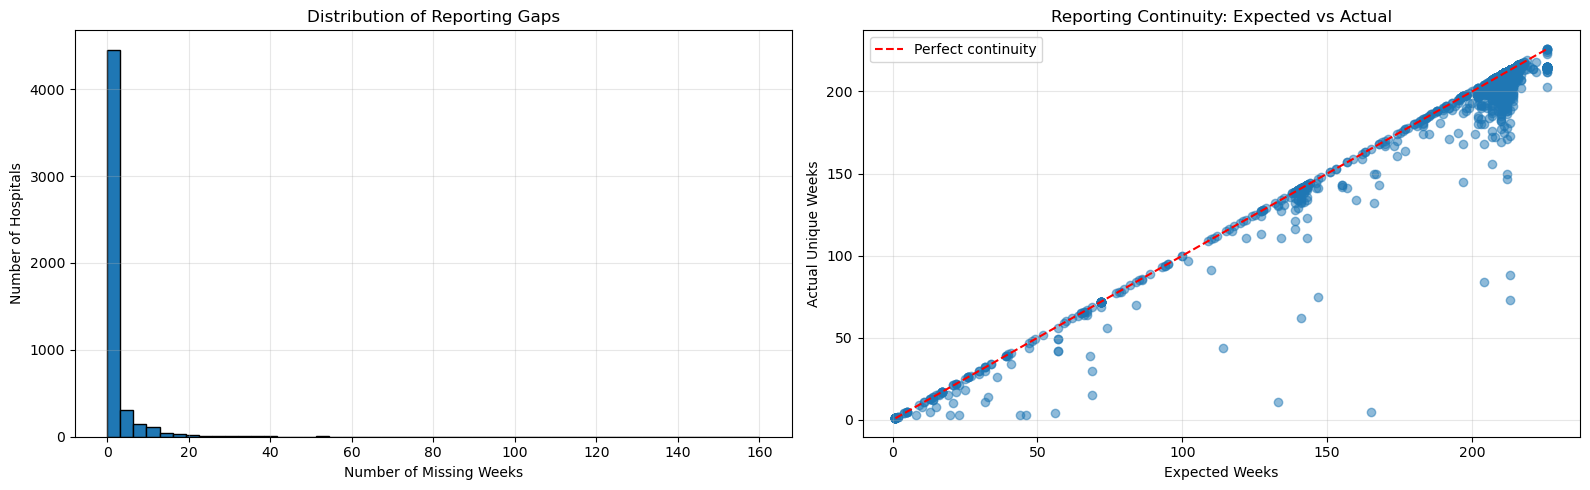

In [6]:
# For each hospital, determine first and last appearance
hospital_stats = df.groupby('hospital_pk').agg({
    'collection_week': ['min', 'max', 'count', 'nunique'],
    'state': 'first',
    'hospital_name': 'first'
}).reset_index()
hospital_stats.columns = ['hospital_pk', 'first_week', 'last_week', 'total_records', 'unique_weeks', 'state', 'hospital_name']

# Calculate expected vs actual weeks for each hospital
hospital_stats['expected_weeks'] = (
    (pd.to_datetime(hospital_stats['last_week']) - pd.to_datetime(hospital_stats['first_week'])).dt.days / 7
).round().astype(int) + 1
hospital_stats['reporting_gaps'] = hospital_stats['expected_weeks'] - hospital_stats['unique_weeks']

print(f"Total hospitals in dataset: {len(hospital_stats)}")
print(f"\nReporting continuity statistics:")
print(f"  Hospitals with continuous reporting: {(hospital_stats['reporting_gaps'] == 0).sum()} ({(hospital_stats['reporting_gaps'] == 0).sum() / len(hospital_stats) * 100:.1f}%)")
print(f"  Hospitals with gaps in reporting: {(hospital_stats['reporting_gaps'] > 0).sum()} ({(hospital_stats['reporting_gaps'] > 0).sum() / len(hospital_stats) * 100:.1f}%)")

# Identify hospitals with significant gaps (>2 consecutive weeks missing)
significant_gaps = hospital_stats[hospital_stats['reporting_gaps'] > 2]
print(f"  Hospitals with >2 missing weeks: {len(significant_gaps)} ({len(significant_gaps) / len(hospital_stats) * 100:.1f}%)")

# Analyze start and stop dates
print("\n\n=== Hospital Reporting Start/Stop Analysis ===")
print(f"Earliest hospital start date: {hospital_stats['first_week'].min()}")
print(f"Latest hospital start date: {hospital_stats['first_week'].max()}")
print(f"Earliest hospital stop date: {hospital_stats['last_week'].min()}")
print(f"Latest hospital stop date: {hospital_stats['last_week'].max()}")

# Show hospitals that started/stopped reporting over time
print("\n\nHospitals starting to report by year-month:")
hospital_stats['start_year_month'] = pd.to_datetime(hospital_stats['first_week']).dt.to_period('M')
print(hospital_stats['start_year_month'].value_counts().sort_index().head(10))

print("\n\nHospitals stopping to report by year-month:")
hospital_stats['stop_year_month'] = pd.to_datetime(hospital_stats['last_week']).dt.to_period('M')
print(hospital_stats['stop_year_month'].value_counts().sort_index().tail(10))

# Show hospitals that are still reporting at the end of the dataset
end_date = df['collection_week'].max()
still_reporting = hospital_stats[hospital_stats['last_week'] == end_date]
print(f"\n\nHospitals still reporting as of {end_date.date()}: {len(still_reporting)} ({len(still_reporting)/len(hospital_stats)*100:.1f}%)")

# Distribution of gap sizes
print("\n\nDistribution of reporting gaps:")
print(hospital_stats['reporting_gaps'].describe())

# Visualize reporting continuity
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(16, 5))

ax1.hist(hospital_stats['reporting_gaps'], bins=50, edgecolor='black')
ax1.set_xlabel('Number of Missing Weeks')
ax1.set_ylabel('Number of Hospitals')
ax1.set_title('Distribution of Reporting Gaps')
ax1.grid(True, alpha=0.3)

ax2.scatter(hospital_stats['expected_weeks'], hospital_stats['unique_weeks'], alpha=0.5)
ax2.plot([hospital_stats['expected_weeks'].min(), hospital_stats['expected_weeks'].max()],
         [hospital_stats['expected_weeks'].min(), hospital_stats['expected_weeks'].max()],
         'r--', label='Perfect continuity')
ax2.set_xlabel('Expected Weeks')
ax2.set_ylabel('Actual Unique Weeks')
ax2.set_title('Reporting Continuity: Expected vs Actual')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
### Hospital reporting continuity timeline

# Get reporting intervals for each hospital
hospital_reporting = df.groupby('hospital_pk')['collection_week'].apply(lambda x: sorted(x.unique())).reset_index()
hospital_reporting.columns = ['hospital_pk', 'reporting_weeks']

# Sort hospitals by first reporting date for better visualization
hospital_first_week = df.groupby('hospital_pk')['collection_week'].min().reset_index()
hospital_first_week.columns = ['hospital_pk', 'first_week']
hospital_reporting = hospital_reporting.merge(hospital_first_week, on='hospital_pk')
hospital_reporting = hospital_reporting.sort_values('first_week').reset_index(drop=True)

# Convert dates to numeric for plotting
start_date = df['collection_week'].min()
hospital_reporting['reporting_weeks_numeric'] = hospital_reporting['reporting_weeks'].apply(
    lambda weeks: sorted([(pd.to_datetime(w) - start_date).days for w in weeks])
)

# Create the plot
fig, ax = plt.subplots(figsize=(16, max(10, len(hospital_reporting) * 0.1)))

# Prepare data for broken_barh: list of (start, width) tuples for each hospital
bars = []
for idx, row in hospital_reporting.iterrows():
    weeks_numeric = row['reporting_weeks_numeric']
    if not weeks_numeric:
        bars.append([])
        continue
    
    # Group consecutive weeks into intervals
    intervals = []
    interval_start = weeks_numeric[0]
    last_week = weeks_numeric[0]
    
    for i in range(1, len(weeks_numeric)):
        current_week = weeks_numeric[i]
        # If weeks are consecutive (within 14 days to account for weekly reporting)
        if current_week - last_week <= 14:
            last_week = current_week
        else:
            # Save current interval (width includes the full week)
            intervals.append((interval_start, last_week - interval_start + 7))
            interval_start = current_week
            last_week = current_week
    
    # Add the last interval
    intervals.append((interval_start, last_week - interval_start + 7))
    bars.append(intervals)

# Plot using broken_barh
for idx, intervals in enumerate(bars):
    if intervals:
        ax.broken_barh(intervals, (idx - 0.4, 0.8), facecolors='steelblue', alpha=0.7)

# Set labels and title
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Hospital Index (sorted by first report date)', fontsize=12)
ax.set_title('Hospital Reporting Continuity Timeline', fontsize=14, fontweight='bold')

# Convert x-axis to dates for better readability
date_ticks = pd.date_range(start=start_date, end=df['collection_week'].max(), freq='6M')
date_tick_positions = [(d - start_date).days for d in date_ticks]
ax.set_xticks(date_tick_positions)
ax.set_xticklabels([d.strftime('%Y-%m') for d in date_ticks], rotation=45, ha='right')

# Set y-axis limits
ax.set_ylim(-0.5, len(hospital_reporting) - 0.5)
ax.set_xlim(0, (df['collection_week'].max() - start_date).days)

# Add grid for better readability
ax.grid(True, alpha=0.3, axis='x')

# Add red vertical line at 2020-03-29 with label
marker_date = pd.to_datetime('2020-03-29')
marker_days = (marker_date - start_date).days
ax.axvline(x=marker_days, color='red', linewidth=2, linestyle='--', alpha=0.8)
ax.text(marker_days, len(hospital_reporting) * 0.95, '2020-03-29', 
        rotation=90, verticalalignment='top', horizontalalignment='right',
        color='red', fontsize=10, fontweight='bold', 
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='red'))

plt.tight_layout()
plt.show()

print(f"Total hospitals visualized: {len(hospital_reporting)}")
print(f"Time range: {start_date.date()} to {df['collection_week'].max().date()}")


/local/ipykernel_2837588/301451896.py:61: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date_ticks = pd.date_range(start=start_date, end=df['collection_week'].max(), freq='6M')


Total hospitals visualized: 5172
Time range: 2019-12-29 to 2024-04-21


In [8]:
hospital_first_week = df.groupby('hospital_pk')['collection_week'].min().reset_index()
hospital_first_week.columns = ['hospital_pk', 'first_week']

hospital_first_week.groupby('first_week').size().sort_values(ascending=False).head(10)


first_week
2020-03-29    1703
2020-03-22     882
2020-04-12     671
2020-04-05     540
2020-04-19     441
2020-05-10     223
2020-04-26     125
2020-03-08      84
2020-03-15      63
2020-03-01      60
dtype: int64

### Hospitalization counts vs case counts

In [9]:
## Clean and Validate COVID Hospitalization Column
def clean_numeric(df, col, verbose=False):
    # Make a copy to avoid modifying the original
    df = df.copy()
    
    if verbose:
        print(f"Sample values in {col}:")
        print(df[col].value_counts().head(20))
    
    # Replace suppression value "-999,999" with NaN
    # Suppression is applied when sums/averages are less than 4
    suppression_count = (df[col] == "-999,999").sum() if df[col].dtype == 'object' else (df[col] == -999999).sum()
    if suppression_count > 0:
        df[col] = df[col].replace("-999,999", np.nan)
        df[col] = df[col].replace(-999999, np.nan)
        if verbose:
            print(f"\nSuppressed values (-999,999) replaced with NaN: {suppression_count}")
    
    # Check for non-numeric values
    non_numeric = df[col].apply(lambda x: not pd.isna(x) and not str(x).replace('.', '').replace('-', '').isdigit())
    if verbose:
        print(f"\nNon-numeric values found: {non_numeric.sum()}" )
    
    # Show examples of non-numeric values
    if non_numeric.sum() > 0:
        print("\nSample non-numeric values:")
        print(df[non_numeric][col].value_counts().head(10))
    
    # Convert to numeric, coercing errors to NaN
    clean_col = col + "_clean"
    df[clean_col] = pd.to_numeric(
        df[col], 
        errors='coerce'
    )
    if verbose:
        print(f"\nData cleaning results:")
        print(f"Original missing values: {df[col].isna().sum()}")
        print(f"Cleaned missing values: {df[clean_col].isna().sum()}")
        print(f"Additional rows converted to NaN: {(df[clean_col].isna().sum() - df[col].isna().sum())}")
    
    # Replace the original column with the cleaned version
    df[col] = df[clean_col]
    df = df.drop(clean_col, axis=1)
    
    return df


### Hospitilization counts vs Case Counts

In [10]:
from cgnn import process_data

_, case_df = process_data.process_case_death_data()

/burg/apam/users/nhw2114/.conda/envs/cgnn/lib/python3.12/site-packages/torch_geometric/typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /burg-archive/apam/users/nhw2114/.conda/envs/cgnn/lib/python3.12/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/burg/apam/users/nhw2114/.conda/envs/cgnn/lib/python3.12/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /lib64/libm.so.6: version `GLIBC_2.29' not found (required by /burg-archive/apam/users/nhw2114/.conda/envs/cgnn/lib/python3.12/site-packages/libpyg.so)
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


unique ZIPs in zip-cbsa map: 39502
unique ZIPs in zip-county map: 39490
num zips in cbsa but not county: 15
num zips in county but not cbsa: 3
rows with neg cases: 13983 out of 39517
rows with neg deaths: 10869 out of 39947


In [11]:
national_case_df = case_df.groupby("date")[["CASE_COUNT"]].sum().reset_index()

In [12]:
fig = go.Figure()

# plots averages 
# cols = [col for col in df.columns if "confirmed" in col and "adult" in col and "-" not in col and "+" not in col and "icu" not in col and "previous" not in col and "coverage" not in col]
# cols = cols + ["total_patients_hospitalized_confirmed_influenza_and_covid_7_day_avg", "total_patients_hospitalized_confirmed_influenza_and_covid_7_day_sum"] 
cols = ['total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_sum', 'total_adult_patients_hospitalized_confirmed_covid_7_day_sum']

for col in cols:
    df = clean_numeric(df, col)

for col in cols:
    national_covid = df.groupby('collection_week')[col].sum().reset_index()
    national_covid = national_covid.sort_values('collection_week')
    fig.add_trace(go.Scatter(
        x=national_covid['collection_week'],
        y=national_covid[col],
        mode='lines',
        name=f'{col}',
        hovertemplate='Date: %{x|%Y-%m-%d}<br>' +
                      f'{col}: %{{y:,.0f}}' +
                      '<extra></extra>'
    ))

#  add case data
fig.add_trace(go.Scatter(
        x=national_case_df['date'],
        y=national_case_df['CASE_COUNT'],
        mode='lines',
        # line=dict(color='red'),
        name='CASE_COUNT',
        hovertemplate='Date: %{x|%Y-%m-%d}<br>' +
                      'CASE_COUNT: %{y:,.0f}' +
                      '<extra></extra>'
    ))

fig.update_layout(
    title='National COVID-19 Hospitalizations Over Time',
    xaxis_title='Date',
    yaxis_title='Total COVID Hospitalizations (7-day avg)',
    hovermode='x unified',
    height=500,
    width=1200,
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.01
    )
)

fig.show()



Sample non-numeric values:
total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_sum
1,031    17
1,131    16
1,041    14
1,000    14
1,062    14
1,099    14
1,071    13
1,017    13
1,042    13
1,010    13
Name: count, dtype: int64

Sample non-numeric values:
total_adult_patients_hospitalized_confirmed_covid_7_day_sum
1,034    12
1,047    11
1,011    10
1,042    10
1,001     9
1,016     9
1,026     9
1,093     9
1,126     9
1,050     9
Name: count, dtype: int64


In [13]:
from scipy.stats import pearsonr

cutoff_date = '2020-07-01'
hospitalization_col = 'total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_sum'

df['collection_week'] = pd.to_datetime(df['collection_week'])
national_hospitalizations = df.groupby('collection_week')[hospitalization_col].sum().reset_index()
national_hospitalizations = national_hospitalizations.rename(columns={'collection_week': 'date'})
national_hospitalizations['date'] = national_hospitalizations['date'] + pd.to_timedelta('1 day')

national_case_df['date'] = pd.to_datetime(national_case_df['date'])
national_cases = national_case_df[['date', 'CASE_COUNT']]

merged_data = pd.merge(national_hospitalizations, national_cases, on='date', how='inner')
merged_data = merged_data.loc[merged_data['date'] > cutoff_date]

correlation_data = merged_data.dropna(subset=[hospitalization_col, 'CASE_COUNT'])


correlation_coefficient, p_value = pearsonr(
    correlation_data[hospitalization_col],
    correlation_data['CASE_COUNT']
)

# --- Step 6: Display the results ---
print(f"The Pearson correlation coefficient between '{hospitalization_col}' and 'CASE_COUNT' is: {correlation_coefficient:.4f}")
print(f"The 2-tailed p-value is: {p_value:.4f}")


The Pearson correlation coefficient between 'total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_sum' and 'CASE_COUNT' is: 0.5595
The 2-tailed p-value is: 0.0030


## 2. Clean hospital data

In [14]:
def filter_by_reporting_pct(df, cutoff_date='2020-07-12', max_missing_weeks=0):
    """
    Filter hospitals by maximum number of missing weeks after cutoff_date.
    
    Args:
        df: DataFrame with hospital data
        cutoff_date: Date to start counting from (default: '2020-07-12')
        max_missing_weeks: Maximum number of missing weeks allowed (default: 0)
    
    Returns:
        filtered_df: DataFrame with only hospitals meeting criteria
        dropped_stats: Dictionary with summary of dropped hospitals
    """
    # Convert cutoff_date to datetime
    cutoff_date = pd.to_datetime(cutoff_date)
    
    # Filter data to post-cutoff period
    df_filtered = df[df['collection_week'] >= cutoff_date].copy()
    
    # Calculate total time series length from cutoff to end
    end_date = df['collection_week'].max()
    total_weeks = len(pd.date_range(start=cutoff_date, end=end_date, freq='W'))
    
    # Calculate reporting statistics per hospital
    hospital_reporting = df_filtered.groupby('hospital_pk').agg({
        'collection_week': 'nunique',
        'state': 'first',
    }).reset_index()
    hospital_reporting.columns = ['hospital_pk', 'unique_weeks', 'state']
    
    # Calculate missing weeks
    hospital_reporting['missing_weeks'] = total_weeks - hospital_reporting['unique_weeks']
    
    # Get hospitals before filtering
    hospitals_before = set(hospital_reporting['hospital_pk'].unique())
    
    # Filter hospitals meeting the maximum missing weeks threshold
    hospitals_meeting_criteria = hospital_reporting[hospital_reporting['missing_weeks'] <= max_missing_weeks]
    hospital_pks_to_keep = set(hospitals_meeting_criteria['hospital_pk'].unique())
    
    # Filter the original dataframe
    filtered_df = df[df['hospital_pk'].isin(hospital_pks_to_keep)].copy()
    
    # Calculate dropped statistics
    hospitals_after = hospital_pks_to_keep
    hospitals_dropped = hospitals_before - hospitals_after
    
    # Calculate original counts by state
    original_by_state = hospital_reporting.groupby('state').size()
    
    # Calculate dropped counts by state
    dropped_by_state = hospital_reporting[hospital_reporting['hospital_pk'].isin(hospitals_dropped)].groupby('state').size()
    
    # Create DataFrame with state statistics
    state_stats = pd.DataFrame({
        'original_count': original_by_state,
        'dropped_count': dropped_by_state
    }).fillna(0)
    
    # Calculate percent dropped
    state_stats['percent_dropped'] = (state_stats['dropped_count'] / state_stats['original_count'] * 100).round(2)
    
    # Sort by percent dropped (descending)
    state_stats = state_stats.sort_values('percent_dropped', ascending=False)
    
    dropped_stats = {
        'total_before': len(hospitals_before),
        'total_after': len(hospitals_after),
        'total_dropped': len(hospitals_dropped),
        'state_stats': state_stats
    }
    
    return filtered_df, dropped_stats

# Apply the filter
CUTOFF_DATE = '2020-07-12'
MAX_MISSING_WEEKS = 0  # No missing weeks allowed

df_filtered, dropped_stats = filter_by_reporting_pct(df, cutoff_date=CUTOFF_DATE, max_missing_weeks=MAX_MISSING_WEEKS)

# Print statistics
print(f"Filtering hospitals by maximum missing weeks (<= {MAX_MISSING_WEEKS}) after {CUTOFF_DATE}")
print(f"\nTotal hospitals before filtering: {dropped_stats['total_before']}")
print(f"Total hospitals after filtering: {dropped_stats['total_after']}")
print(f"Total hospitals dropped: {dropped_stats['total_dropped']}")
print(f"\nHospitals dropped by state (ordered by percent dropped):")
print(dropped_stats['state_stats'])


Filtering hospitals by maximum missing weeks (<= 0) after 2020-07-12

Total hospitals before filtering: 5163
Total hospitals after filtering: 4028
Total hospitals dropped: 1135

Hospitals dropped by state (ordered by percent dropped):
       original_count  dropped_count  percent_dropped
state                                                
AS                  1            1.0           100.00
MP                  1            1.0           100.00
ND                 45           27.0            60.00
NM                 41           22.0            53.66
VI                  2            1.0            50.00
PR                 62           30.0            48.39
GA                145           52.0            35.86
MS                102           35.0            34.31
OK                130           43.0            33.08
OR                 61           20.0            32.79
KS                137           44.0            32.12
IN                127           40.0            31.50
AR       

In [15]:
df_filtered.groupby('hospital_subtype')['hospital_pk'].nunique()


hospital_subtype
Childrens Hospitals            65
Critical Access Hospitals    1066
Long Term                     185
Short Term                   2712
Name: hospital_pk, dtype: int64

In [16]:
# Test different max_missing_weeks values from 0 to 20
max_missing_weeks_values = np.arange(0, 50, 1)  # 0, 1, 2, ..., 20

# Store results
results = {
    'max_missing_weeks': [],
    'total_dropped_pct': [],
    'state_dropped_pct': {}
}

# Store original counts (same for all max_missing_weeks values, get from first iteration)
state_original_counts = {}

# Run filter for each max_missing_weeks value
for max_missing_weeks in tqdm(max_missing_weeks_values):
    _, dropped_stats = filter_by_reporting_pct(df, cutoff_date=CUTOFF_DATE, max_missing_weeks=max_missing_weeks)
    
    # Calculate overall percent dropped
    total_dropped_pct = (dropped_stats['total_dropped'] / dropped_stats['total_before']) * 100
    
    results['max_missing_weeks'].append(max_missing_weeks)
    results['total_dropped_pct'].append(total_dropped_pct)
    
    # Store state-level percent dropped and original counts (only need to do this once)
    for state, row in dropped_stats['state_stats'].iterrows():
        if state not in results['state_dropped_pct']:
            results['state_dropped_pct'][state] = []
            state_original_counts[state] = int(row['original_count'])
        results['state_dropped_pct'][state].append(row['percent_dropped'])

# Calculate percent included (100 - percent dropped)
total_included_pct = [100 - pct for pct in results['total_dropped_pct']]
state_included_pct = {}
for state in results['state_dropped_pct'].keys():
    state_included_pct[state] = [100 - pct for pct in results['state_dropped_pct'][state]]

100%|██████████| 50/50 [09:40<00:00, 11.61s/it]


In [17]:
# Get color palette for states
import plotly.colors as pc

n_states = len(state_included_pct)
colors = pc.qualitative.Set3 * (n_states // len(pc.qualitative.Set3) + 1)
state_colors = {state: colors[i] for i, state in enumerate(sorted(state_included_pct.keys()))}

# Create plotly plot
fig = go.Figure()

# Plot percent included for each state first (so Total appears on top)
for state in sorted(state_included_pct.keys()):
    original_count = state_original_counts[state]
    fig.add_trace(go.Scatter(
        x=results['max_missing_weeks'],
        y=state_included_pct[state],
        mode='lines',
        name=state,
        line=dict(width=2, color=state_colors[state]),
        hovertemplate=f'State: {state}<br>' +
                      f'Original Hospitals: {original_count}<br>' +
                      'Max Missing Weeks: %{x}<br>' +
                      'Percent Included: %{y:.2f}%<extra></extra>'
    ))

# Plot overall percent included last (so it appears on top)
fig.add_trace(go.Scatter(
    x=results['max_missing_weeks'],
    y=total_included_pct,
    mode='lines+markers',
    name='Total',
    line=dict(width=3, color='black', dash='dash'),
    marker=dict(size=8),
    hovertemplate='Total<br>' +
                  'Max Missing Weeks: %{x}<br>' +
                  'Percent Included: %{y:.2f}%<extra></extra>'
))

fig.update_layout(
    title='Hospital Inclusion Rates by Maximum Missing Weeks Threshold<br>(Overall and by State)',
    xaxis_title='Maximum Missing Weeks Allowed',
    yaxis_title='Percent of Hospitals Included (%)',
    hovermode='closest',
    height=600,
    width=1200,
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.01
    ),
    xaxis=dict(range=[0, 50])
)

fig.show()

print(f"Analyzed {len(max_missing_weeks_values)} different maximum missing weeks thresholds")
print(f"Total states: {len(results['state_dropped_pct'])}")


Analyzed 50 different maximum missing weeks thresholds
Total states: 56


## `MAX_MISSING_WEEKS = 21`

Chosen so that we have at least 75% of PR hospitals and 92.68% of hospitals nationally.

After cutting off with `CUTOFF_DATE = '2020-07-12'`, there are 226 weeks in our data. So 21 weeks is less than 10\%.



In [18]:
MAX_MISSING_WEEKS = 21

# Save original df before filtering for comparison plots
df_unfiltered = df.copy()

df_filtered, dropped_stats = filter_by_reporting_pct(df, cutoff_date=CUTOFF_DATE, max_missing_weeks=MAX_MISSING_WEEKS)


In [19]:
len(set(df_unfiltered.hospital_pk) - set(df_filtered.hospital_pk))


387

In [20]:
387 / df_unfiltered.hospital_pk.nunique()

0.07482598607888631

In [21]:
fig = go.Figure()

# plots averages 
# cols = [col for col in df.columns if "confirmed" in col and "adult" in col and "-" not in col and "+" not in col and "icu" not in col and "previous" not in col and "coverage" not in col]
# cols = cols + ["total_patients_hospitalized_confirmed_influenza_and_covid_7_day_avg", "total_patients_hospitalized_confirmed_influenza_and_covid_7_day_sum"] 
cols = ['total_adult_patients_hospitalized_confirmed_and_suspected_covid_7_day_sum', 'total_adult_patients_hospitalized_confirmed_covid_7_day_sum']

# Get plotly default colors
import plotly.colors as pc
default_colors = pc.qualitative.Plotly

# Clean and plot unfiltered data first (solid lines)
df_unfiltered_clean = df_unfiltered.copy()
for col in cols:
    df_unfiltered_clean = clean_numeric(df_unfiltered_clean, col)

for idx, col in enumerate(cols):
    national_covid_unfiltered = df_unfiltered_clean.groupby('collection_week')[col].sum().reset_index()
    national_covid_unfiltered = national_covid_unfiltered.sort_values('collection_week')
    color = default_colors[idx % len(default_colors)]
    fig.add_trace(go.Scatter(
        x=national_covid_unfiltered['collection_week'],
        y=national_covid_unfiltered[col],
        mode='lines',
        name=f'{col} (unfiltered)',
        line=dict(color=color),
        hovertemplate='Date: %{x|%Y-%m-%d}<br>' +
                      f'{col} (unfiltered): %{{y:,.0f}}' +
                      '<extra></extra>'
    ))

# Clean and plot filtered data (dashed lines, same colors)
for col in cols:
    df_filtered = clean_numeric(df_filtered, col)

for idx, col in enumerate(cols):
    national_covid = df_filtered.groupby('collection_week')[col].sum().reset_index()
    national_covid = national_covid.sort_values('collection_week')
    color = default_colors[idx % len(default_colors)]
    fig.add_trace(go.Scatter(
        x=national_covid['collection_week'],
        y=national_covid[col],
        mode='lines',
        name=f'{col} (filtered)',
        line=dict(color=color, dash='dash'),
        hovertemplate='Date: %{x|%Y-%m-%d}<br>' +
                      f'{col} (filtered): %{{y:,.0f}}' +
                      '<extra></extra>'
    ))

#  add case data
fig.add_trace(go.Scatter(
        x=national_case_df['date'],
        y=national_case_df['CASE_COUNT'],
        mode='lines',
        # line=dict(color='red'),
        name='CASE_COUNT',
        hovertemplate='Date: %{x|%Y-%m-%d}<br>' +
                      'CASE_COUNT: %{y:,.0f}' +
                      '<extra></extra>'
    ))

fig.update_layout(
    title='National COVID-19 Hospitalizations Over Time',
    xaxis_title='Date',
    yaxis_title='Total COVID Hospitalizations (7-day avg)',
    hovermode='x unified',
    height=500,
    width=1200,
    legend=dict(
        orientation="v",
        yanchor="top",
        y=1,
        xanchor="left",
        x=1.01
    )
)

fig.show()


## 3. Counts of hospitals before and after filtering

In [22]:
filtered_counts = df_filtered.groupby('state')['hospital_pk'].nunique()
unfiltered_counts = df_unfiltered.groupby('state')['hospital_pk'].nunique()

counts_merged = pd.merge(filtered_counts, unfiltered_counts, on='state', how='left')
counts_merged.columns = ['filtered', 'unfiltered']
counts_merged['pct_remaining'] = counts_merged['filtered'] / counts_merged['unfiltered'] * 100
counts_merged.sort_values('pct_remaining', ascending=True)

,filtered,unfiltered,pct_remaining
state,,,
PR,47,62,75.806452
NM,35,42,83.333333
NV,39,46,84.782609
OK,112,130,86.153846
LA,131,152,86.184211
PA,164,190,86.315789
AZ,70,81,86.419753
AK,14,16,87.500000
TX,415,474,87.552743


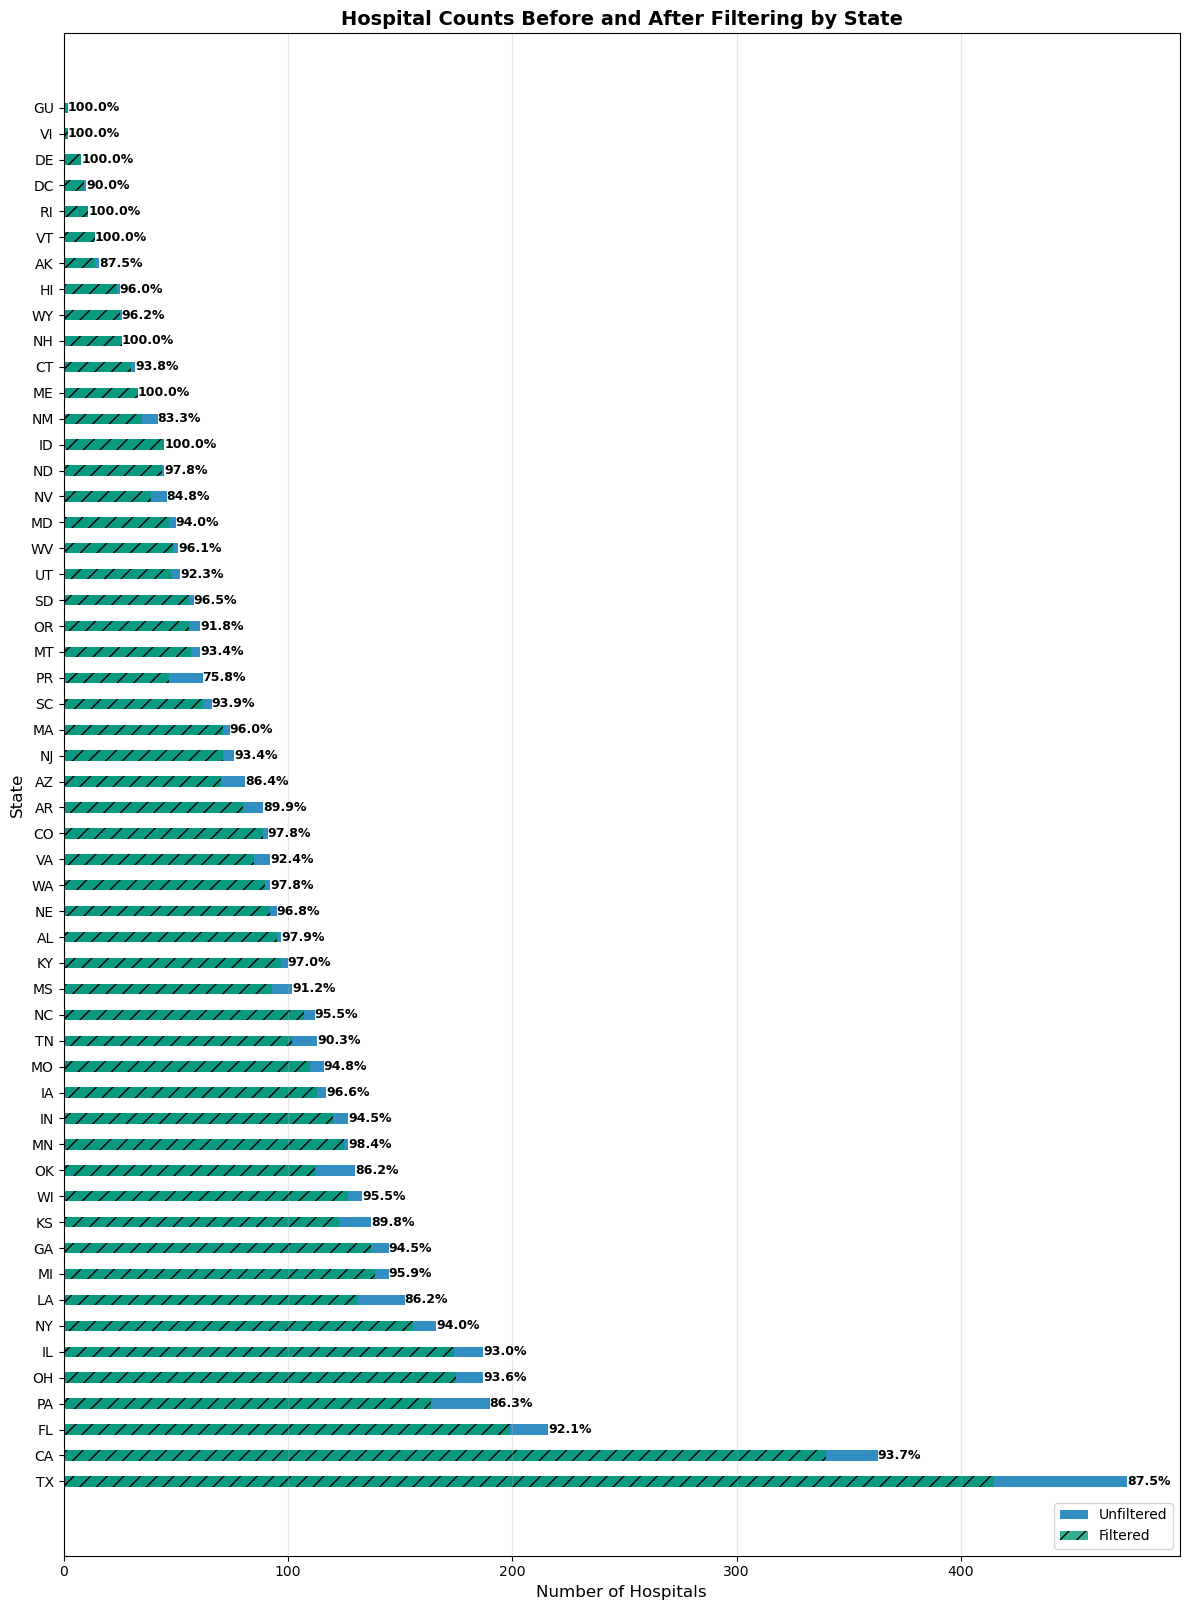

In [23]:
# Set seaborn style
plt.style.use('seaborn-v0_8-colorblind')

# Prepare data for plotting - sort by unfiltered count for better visualization
counts_plot = counts_merged.sort_values('unfiltered', ascending=True).reset_index()

# Create the plot
fig, ax = plt.subplots(figsize=(12, max(8, len(counts_plot) * 0.3)))

# Get the number of states
n_states = len(counts_plot)
y_pos = np.arange(n_states)

# Plot unfiltered counts first (hatched bars, full length) - this will be the background
bars_unfiltered = ax.barh(y_pos, counts_plot['unfiltered'], 
                          label='Unfiltered', alpha=0.8, height=0.4)

# Plot filtered counts on top (solid bars, shorter length) - this will overlay
bars_filtered = ax.barh(y_pos, counts_plot['filtered'], hatch='//',
                        label='Filtered', alpha=0.8, height=0.4)

# Calculate percentage remaining and add text at the end of each bar
counts_plot['pct_remaining'] = (counts_plot['filtered'] / counts_plot['unfiltered'] * 100).round(2)
for i, (idx, row) in enumerate(counts_plot.iterrows()):
    # Place text at the end of the filtered bar
    ax.text(row['unfiltered'], y_pos[i], f"{row['pct_remaining']:.1f}%",
            va='center', ha='left', fontsize=9, fontweight='bold')

# Set y-axis labels
ax.set_yticks(y_pos)
ax.set_yticklabels(counts_plot['state'])
ax.invert_yaxis()  # Top to bottom

# Labels and title
ax.set_xlabel('Number of Hospitals', fontsize=12)
ax.set_ylabel('State', fontsize=12)
ax.set_title('Hospital Counts Before and After Filtering by State', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')

# Add grid for better readability
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


## 4. Look at hospitals before 07/13/2020

In [64]:
from cgnn.utils import get_cbsa_info

cbsa_info = get_cbsa_info()
cbsa_state = cbsa_info[['CBSA Code', 'State Name']].drop_duplicates()
case_state_df = case_df.merge(cbsa_state, left_on='CBSA', right_on='CBSA Code', how='left')
case_state_df.loc[case_state_df['date'] < '2020-07-13'].groupby('State Name')['CASE_COUNT'].sum().sort_values(ascending=False)

State Name
New Jersey              91718.044505
New York                86694.928571
Florida                 61487.714286
California              54810.387755
Texas                   51948.857143
Indiana                 25078.428571
Arizona                 24739.857143
Illinois                21439.214286
Maryland                21123.455769
Georgia                 19517.071429
Massachusetts           17122.785714
Pennsylvania            16175.830220
Louisiana               15402.142857
South Carolina          15190.714286
North Carolina          13826.071429
Virginia                12949.102679
Michigan                12264.714286
New Hampshire           11445.642857
Tennessee               11390.814286
Ohio                    10999.357143
West Virginia           10494.823695
Wisconsin                9854.785714
Delaware                 9627.687363
Alabama                  9550.021978
District of Columbia     9331.174107
Minnesota                8042.642857
Iowa                     75

In [41]:
pre_july_df = df_filtered.loc[
    (df_filtered['collection_week'] < '2020-07-13') &
    (df_filtered['total_adult_patients_hospitalized_confirmed_covid_7_day_sum'] > 0)
]

pre_july_df.groupby('state')['total_adult_patients_hospitalized_confirmed_covid_7_day_sum'].sum().sort_values(ascending=False)

state
LA    46271.0
CA    43102.0
TX    24128.0
FL    23093.0
NV    14428.0
AZ    13701.0
TN     5803.0
GA     5456.0
AL     5368.0
SC     4481.0
IA     3028.0
NC     2877.0
OK     2569.0
NY     2283.0
IL     2161.0
VA     1960.0
MS     1942.0
MO     1928.0
OH     1819.0
AR     1579.0
MD     1237.0
PA     1183.0
IN     1129.0
CO      997.0
NE      994.0
WA      991.0
WI      984.0
MA      820.0
ID      612.0
UT      598.0
NJ      571.0
KS      542.0
MI      460.0
OR      456.0
RI      353.0
NM      325.0
PR      274.0
WV      227.0
MN      168.0
DE      158.0
MT      100.0
SD       92.0
CT       82.0
HI       80.0
DC       75.0
WY       71.0
NH       63.0
AK       35.0
VI       29.0
KY       27.0
ME       21.0
VT       16.0
GU        7.0
Name: total_adult_patients_hospitalized_confirmed_covid_7_day_sum, dtype: float64

In [38]:
# Compute the number of hospitals with non-zero COVID cases before 2020-07-13 in each state
pre_july_hospitals = df_filtered.loc[
    (df_filtered['collection_week'] < '2020-07-13') &
    (df_filtered['total_adult_patients_hospitalized_confirmed_covid_7_day_sum'] > 0)
].groupby('state')['hospital_pk'].nunique()

# Compute the total number of hospitals in each state
total_hospitals = df_filtered.groupby('state')['hospital_pk'].nunique()

# Calculate the proportion
proportion_pre_july = (pre_july_hospitals / total_hospitals).fillna(0)

# Optional: display as a DataFrame for clarity
proportion_pre_july_df = proportion_pre_july.reset_index(name='proportion_nonzero_pre_07132020')
display(proportion_pre_july_df.sort_values('proportion_nonzero_pre_07132020', ascending=False))


,state,proportion_nonzero_pre_07132020
48,VI,1.000000
4,CA,0.800000
1,AL,0.747368
19,LA,0.709924
21,MD,0.702128
34,NV,0.692308
42,SC,0.677419
9,FL,0.663317
3,AZ,0.628571
44,TN,0.578431
